<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [ ]:
# Parameters
vocab_size = 10000
maxlen = 200

# Load IMDb dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)


Training RNN model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.6430 - loss: 0.6222 - val_accuracy: 0.6990 - val_loss: 0.5860
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.8317 - loss: 0.3963 - val_accuracy: 0.8286 - val_loss: 0.3959
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8981 - loss: 0.2569 - val_accuracy: 0.8394 - val_loss: 0.3815

Training LSTM model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.7555 - loss: 0.4953 - val_accuracy: 0.8606 - val_loss: 0.3403
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.8969 - loss: 0.2637 - val_accuracy: 0.8348 - val_loss: 0.4154
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9266 - loss: 0.1980 - val_accuracy: 0.8790 - val_loss: 0.3102

Training GRU model...
Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.7075 - loss: 0.5363 - val_accuracy: 0.8288 - val_loss: 0.4125
Epoch 2/3
157/157 ━━━━━━━━━━━

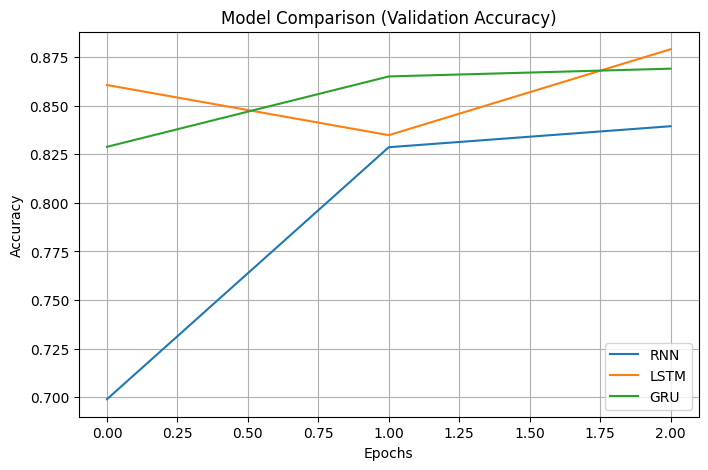

In [ ]:

# Pad sequences
X_train = pad_sequences(X_train, maxlen=maxlen)
X_test = pad_sequences(X_test, maxlen=maxlen)

# Function to build models
def build_model(model_type):
    model = Sequential()

    # Embedding layer
    model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen))

    # Choose model type
    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))

    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Train models
models = ["RNN", "LSTM", "GRU"]
history_dict = {}

for m in models:
    print(f"\nTraining {m} model...")
    model = build_model(m)

    history = model.fit(
        X_train, y_train,
        epochs=3,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    history_dict[m] = history

# Plot learning curves
plt.figure(figsize=(8,5))

for m in models:
    plt.plot(history_dict[m].history['val_accuracy'], label=m)

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()